In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. Dataset-ul Multi-Task (Returnează 2 etichete)
# ==========================================
class APTOSMultiTaskDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.dataframe = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = str(self.dataframe.iloc[idx, 0])
        if not img_name.endswith('.png'):
            img_name += '.png'
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        # Eticheta 1: Gradarea (0, 1, 2, 3, 4) - necesită LongTensor
        label_grade = int(self.dataframe.iloc[idx, 1])
        label_grade_tensor = torch.tensor(label_grade, dtype=torch.long)
        
        # Eticheta 2: Detecția (0 vs 1) - necesită FloatTensor pentru BCE
        label_det = 0 if label_grade == 0 else 1
        label_det_tensor = torch.tensor(label_det, dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label_det_tensor, label_grade_tensor

In [3]:
# ==========================================
# 2. Preprocesare și DataLoaders
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = APTOSMultiTaskDataset("Dataset_APTOS_2019/train_1.csv", "Dataset_APTOS_2019/train_images/train_images", train_transforms)
test_dataset = APTOSMultiTaskDataset("Dataset_APTOS_2019/test.csv", "Dataset_APTOS_2019/test_images/test_images", test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [4]:
# ==========================================
# 3. Arhitectura Multi-Task Custom
# ==========================================
class MultiTaskResNet(nn.Module):
    def __init__(self):
        super(MultiTaskResNet, self).__init__()
        # Extractorul de bază (ResNet50)
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        # Înghețăm baza
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        num_ftrs = self.backbone.fc.in_features
        # Eliminăm clasificatorul standard din ResNet
        self.backbone.fc = nn.Identity() 
        
        # Creăm cele două capete independente
        # Capul 1: Detecție binară (1 neuron)
        self.detection_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1)
        )
        # Capul 2: Gradare 5 clase (5 neuroni)
        self.grading_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 5)
        )

    def forward(self, x):
        features = self.backbone(x)
        out_det = self.detection_head(features)
        out_grade = self.grading_head(features)
        return out_det, out_grade

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskResNet().to(device)

In [5]:
# ==========================================
# 4. Cele două funcții de Cost și Optimizatorul
# ==========================================
criterion_det = nn.BCEWithLogitsLoss()
criterion_grade = nn.CrossEntropyLoss()

# Optimizăm doar greutățile celor două capete noi adăugate
optimizer = optim.Adam(list(model.detection_head.parameters()) + list(model.grading_head.parameters()), lr=0.001)

In [6]:
# ==========================================
# 5. Bucla de Antrenare Multi-Task
# ==========================================
num_epochs = 50

istoric_train_loss = []
istoric_test_loss = []
best_test_loss = float('inf')
cale_model_salvat = "cel_mai_bun_model_multitask.pth"

print("Începe antrenamentul Multi-Task...")
for epoch in range(num_epochs):
    
    # --- TRAIN ---
    model.train()
    running_train_loss = 0.0
    
    for images, labels_det, labels_grade in train_loader:
        images = images.to(device)
        labels_det = labels_det.to(device).unsqueeze(1)
        labels_grade = labels_grade.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass dă 2 ieșiri acum
        out_det, out_grade = model(images)
        
        # Calculăm pierderea totală
        loss_det = criterion_det(out_det, labels_det)
        loss_grade = criterion_grade(out_grade, labels_grade)
        total_loss = loss_det + loss_grade # Ponderare egală (1:1)
        
        total_loss.backward()
        optimizer.step()
        
        running_train_loss += total_loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    istoric_train_loss.append(avg_train_loss)
    
    # --- TEST / VALIDATION ---
    model.eval()
    running_test_loss = 0.0
    
    with torch.no_grad():
        for images, labels_det, labels_grade in test_loader:
            images = images.to(device)
            labels_det = labels_det.to(device).unsqueeze(1)
            labels_grade = labels_grade.to(device)
            
            out_det, out_grade = model(images)
            
            loss_det = criterion_det(out_det, labels_det)
            loss_grade = criterion_grade(out_grade, labels_grade)
            total_loss = loss_det + loss_grade
            
            running_test_loss += total_loss.item()
            
    avg_test_loss = running_test_loss / len(test_loader)
    istoric_test_loss.append(avg_test_loss)
    
    print(f"Epoca [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), cale_model_salvat)
        print(f"  -> Model nou salvat (Scor combinat mai bun: {best_test_loss:.4f})")

Începe antrenamentul Multi-Task...
Epoca [1/50] | Train Loss: 1.3939 | Test Loss: 0.9453
  -> Model nou salvat (Scor combinat mai bun: 0.9453)
Epoca [2/50] | Train Loss: 1.0448 | Test Loss: 0.8267
  -> Model nou salvat (Scor combinat mai bun: 0.8267)
Epoca [3/50] | Train Loss: 0.9454 | Test Loss: 0.8535
Epoca [4/50] | Train Loss: 0.9436 | Test Loss: 0.8086
  -> Model nou salvat (Scor combinat mai bun: 0.8086)
Epoca [5/50] | Train Loss: 0.9111 | Test Loss: 0.7353
  -> Model nou salvat (Scor combinat mai bun: 0.7353)
Epoca [6/50] | Train Loss: 0.8814 | Test Loss: 0.7685
Epoca [7/50] | Train Loss: 0.8749 | Test Loss: 0.7530
Epoca [8/50] | Train Loss: 0.8656 | Test Loss: 0.8143
Epoca [9/50] | Train Loss: 0.8782 | Test Loss: 0.7060
  -> Model nou salvat (Scor combinat mai bun: 0.7060)
Epoca [10/50] | Train Loss: 0.8559 | Test Loss: 0.7667
Epoca [11/50] | Train Loss: 0.8858 | Test Loss: 0.6965
  -> Model nou salvat (Scor combinat mai bun: 0.6965)
Epoca [12/50] | Train Loss: 0.8727 | Test Los


Antrenament finalizat! Graficul a fost salvat.


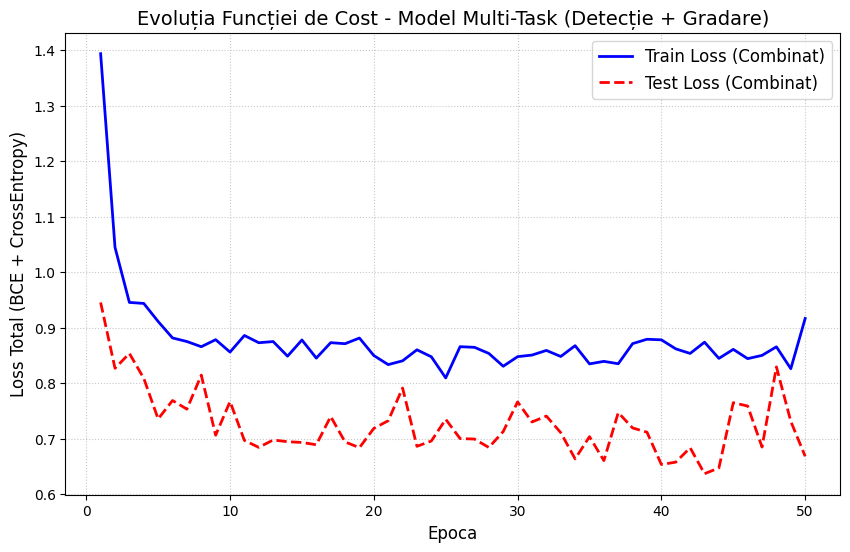

In [7]:
# ==========================================
# 6. Generare Grafic
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), istoric_train_loss, label='Train Loss (Combinat)', color='blue', linewidth=2)
plt.plot(range(1, num_epochs + 1), istoric_test_loss, label='Test Loss (Combinat)', color='red', linestyle='--', linewidth=2)

plt.title('Evoluția Funcției de Cost - Model Multi-Task (Detecție + Gradare)', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Loss Total (BCE + CrossEntropy)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig('grafic_loss_multitask.png', dpi=300, bbox_inches='tight')
print("\nAntrenament finalizat! Graficul a fost salvat.")
plt.show()